# Orphan Well Detection — LiDAR Terrain Analysis

Screens probable orphan and abandoned oil and gas well sites from USGS 3DEP LiDAR using terrain signature analysis and machine learning. The pipeline converts raw LiDAR point cloud tiles to a bare-earth DEM, derives seven terrain layers that capture the characteristic surface expression of historic well pads and access roads, and trains a binary classifier to distinguish engineered depressions from natural landforms.

**Study area:** Western Pennsylvania — birthplace of the U.S. oil industry (1859), highest concentration of historic wells nationally.  
**LiDAR source:** USGS 3DEP airborne, 1 m point spacing, ground-classified (2019).  
**Well records:** PADEP Historic (30,527 wells) + USGS National Orphan Wells (~79,000 after status filtering).

---

In [2]:
!pip install whitebox
!pip install rasterio geopandas scikit-learn rasterstats matplotlib scipy xgboost
!pip install lazrs   # required by laspy to decompress LAZ files; install before importing laspy

Could not find platform independent libraries <prefix>

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Could not find platform independent libraries <prefix>

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Could not find platform independent libraries <prefix>

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [3]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import glob
import random
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Scientific computing ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ── Geospatial — vector and raster I/O ────────────────────────────────────────
import rasterio
from rasterio.merge import merge
from rasterio.crs import CRS
import geopandas as gpd
from shapely.geometry import Point, box

# ── Geospatial — point cloud processing ───────────────────────────────────────
import laspy
import whitebox

# ── Raster statistics ─────────────────────────────────────────────────────────
from rasterstats import point_query, zonal_stats

# ── Image / signal processing ─────────────────────────────────────────────────
from scipy.ndimage import uniform_filter, maximum_filter, minimum_filter

# ── Machine learning ───────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

# ── WhiteboxTools engine ───────────────────────────────────────────────────────
# Verbose mode prints per-tool progress to stdout; set False to suppress.
wbt = whitebox.WhiteboxTools()
wbt.set_verbose_mode(True)

# ── Paths — edit these to match your local layout ─────────────────────────────
LAZ_FOLDER   = r'C:\users\colto\documents\github\lidar_project\data\files'       # raw .laz tiles
DEM_FOLDER   = r'C:\users\colto\documents\github\lidar_project\data\dem_tiles'   # per-tile DEMs
DERIV_FOLDER = r'C:\users\colto\documents\github\lidar_project\data\derivatives' # terrain derivatives
FULL_DEM     = r'C:\users\colto\documents\github\lidar_project\data\full_dem.tif' # mosaicked DEM

# Create output directories if they do not yet exist
os.makedirs(DEM_FOLDER,   exist_ok=True)
os.makedirs(DERIV_FOLDER, exist_ok=True)

print("Setup complete.")

Setup complete.


## Stage 1 — LiDAR to Bare-Earth DEM

Converts raw airborne LiDAR point cloud tiles (LAZ format) to 1-metre bare-earth DEMs using TIN gridding. Only ground-classified returns (Class 2) are retained; all other classes are excluded.

**COPC handling:** Cloud-optimised point cloud tiles must be converted to standard LAZ before processing. The conversion creates a fresh `LasData` object to strip COPC-specific VLRs that otherwise block writing.  
**Incremental:** Tiles that already have a corresponding DEM output are skipped, so re-running after adding new tiles is safe.  
**Parallelised:** Each tile is processed in its own `WhiteboxTools` instance to avoid shared-state issues across threads.

> **Slow on first run** — ~15–30 min for 176 tiles at 4 parallel workers.

In [4]:
# Number of parallel worker threads.
# Keep at or below (physical CPU cores - 1) to avoid saturating disk I/O.
MAX_WORKERS = 4


# ── COPC → standard LAZ conversion ────────────────────────────────────────────
# Cloud-Optimised Point Cloud tiles carry COPC-specific VLRs (variable-length
# records) that block the laspy write path. The fix is to copy all points into
# a fresh LasData object that has no COPC metadata before writing.

def convert_copc(f):
    """Convert a single .copc.laz tile to a standard .laz file.

    Creates a clean LasData object (copying only point_format, version,
    offsets, and scales) and writes it alongside the original .copc.laz.
    The original file is left in place. Skips if output already exists.
    Returns a status string for logging.
    """
    out = f.replace('.copc.laz', '.laz')
    if os.path.exists(out):
        return f"Skipped (exists): {os.path.basename(out)}"

    copc_las = laspy.read(f)

    # Build a fresh header — strips all COPC VLRs that block writing
    new_header         = laspy.LasHeader(
        point_format=copc_las.header.point_format,
        version=copc_las.header.version
    )
    new_header.offsets = copc_las.header.offsets
    new_header.scales  = copc_las.header.scales

    new_las        = laspy.LasData(header=new_header)
    new_las.points = copc_las.points
    new_las.write(out)
    return f"Converted: {os.path.basename(out)}"


copc_files = glob.glob(os.path.join(LAZ_FOLDER, '*.copc.laz'))
if copc_files:
    print(f"Converting {len(copc_files)} COPC files (parallel)...")
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futures = {ex.submit(convert_copc, f): f for f in copc_files}
        for fut in as_completed(futures):
            print(f"  {fut.result()}")
else:
    print("No COPC files found.")


# ── LAZ → bare-earth DEM ───────────────────────────────────────────────────────
# WhiteboxTools lidar_tin_gridding interpolates ground-classified returns
# (Class 2) onto a regular 1-metre TIN grid. All other return classes are
# excluded via the exclude_cls parameter.
#
# Each worker thread instantiates its own WhiteboxTools object — sharing a
# single instance across threads causes race conditions on its internal
# working-directory state.

def process_laz(laz):
    """Interpolate a single LAZ tile to a 1-metre bare-earth DEM GeoTIFF.

    Uses WhiteboxTools TIN gridding on last-return ground points (Class 2).
    Skips tiles that already have a DEM output, making re-runs safe when
    new tiles are added to the input folder.
    Returns a status string for logging.
    """
    basename = os.path.splitext(os.path.basename(laz))[0]
    out_dem  = os.path.join(DEM_FOLDER, f'{basename}_dem.tif')

    if os.path.exists(out_dem):
        return f"Skipped: {basename}"

    _wbt = whitebox.WhiteboxTools()
    _wbt.set_verbose_mode(False)
    _wbt.lidar_tin_gridding(
        i=laz,
        output=out_dem,
        resolution=1.0,                    # 1-metre output grid
        returns='last',                    # last returns are most reliable for ground
        exclude_cls='0,1,3,4,5,6,7,9,17'  # retain Class 2 (ground) only
    )
    return f"Done: {basename}"


# Collect all standard LAZ files; exclude intermediate .copc.laz originals
laz_files = [f for f in glob.glob(os.path.join(LAZ_FOLDER, '*.laz'))
             if '.copc.' not in f]
print(f"\nFound {len(laz_files)} standard LAZ files")

new_tiles = 0
skipped   = 0
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futures = {ex.submit(process_laz, laz): laz for laz in laz_files}
    for fut in as_completed(futures):
        result = fut.result()
        print(f"  {result}")
        if "Skipped" in result:
            skipped += 1
        else:
            new_tiles += 1

print(f"\nNew tiles processed:    {new_tiles}")
print(f"Skipped (already done): {skipped}")

No COPC files found.

Found 4 standard LAZ files
  Skipped: USGS_LPC_PA_WesternPA_2019_D20_17TPF604591
  Skipped: USGS_LPC_PA_WesternPA_2019_D20_17TPF604590
  Skipped: USGS_LPC_PA_WesternPA_2019_D20_17TPF604593
  Skipped: USGS_LPC_PA_WesternPA_2019_D20_17TPF604594

New tiles processed:    0
Skipped (already done): 4


## Stage 2 — DEM Mosaicking

Merges all per-tile bare-earth DEMs into a single continuous surface covering the full study area. The CRS is explicitly reassigned to EPSG:26917 (UTM Zone 17N) after merging because `rasterio.merge` drops the projection metadata.

In [5]:
print("Mosaicking all tiles...")
dem_tiles = glob.glob(os.path.join(DEM_FOLDER, '*_dem.tif'))
print(f"Tiles found: {len(dem_tiles)}")

# Open all per-tile DEMs — rasterio.merge reads lazily so this is fast
src_files = [rasterio.open(f) for f in dem_tiles]

# Merge into a single array; out_transform maps pixel indices to CRS coordinates
mosaic, out_transform = merge(src_files)

# Copy the raster profile from the first tile and update dimensions and CRS.
# CRS must be set explicitly — rasterio.merge drops the projection metadata.
out_profile = src_files[0].profile.copy()
out_profile.update({
    'height':    mosaic.shape[1],
    'width':     mosaic.shape[2],
    'transform': out_transform,
    'crs':       CRS.from_epsg(26917)  # UTM Zone 17N — correct for western PA
})

# Write the mosaicked DEM to disk
with rasterio.open(FULL_DEM, 'w', **out_profile) as dst:
    dst.write(mosaic)

# Close all source file handles
for src in src_files:
    src.close()

# Re-open and report key properties to confirm the output is valid
with rasterio.open(FULL_DEM) as src:
    dem_check = src.read(1).astype('float32')
    dem_check[dem_check == src.nodata] = np.nan
    print(f"\nMosaic updated → {FULL_DEM}")
    print(f"  Shape:     {src.read(1).shape}")
    print(f"  CRS:       {src.crs}")
    print(f"  Elevation: {np.nanmin(dem_check):.1f}m to {np.nanmax(dem_check):.1f}m")

Mosaicking all tiles...
Tiles found: 176

Mosaic updated → C:\users\colto\documents\github\lidar_project\data\full_dem.tif
  Shape:     (19500, 21000)
  CRS:       EPSG:26917
  Elevation: 304.5m to 532.9m


In [6]:
# Read the mosaicked DEM into memory for derivative computation.
# float32 halves memory usage vs float64 with negligible precision loss
# at 1-metre resolution and sub-metre LiDAR vertical accuracy.
with rasterio.open(FULL_DEM) as src:
    dem      = src.read(1).astype('float32')
    profile  = src.profile.copy()  # reused as the base profile for all derivative outputs
    nodata_v = src.nodata

# Update the shared profile so every derivative raster uses float32 and NaN nodata
profile.update(dtype='float32', nodata=np.nan)

# Boolean mask — True where the DEM has valid elevation data
valid_mask = dem != nodata_v

# scipy.ndimage filters propagate NaN outward from nodata areas, which turns
# entire output arrays to NaN when the mosaic has any coverage gaps.
# Fix: fill nodata pixels with the global DEM mean before any filtering,
# then restore the original nodata mask to NaN in each output raster.
fill_value              = float(np.nanmean(dem[valid_mask]))
dem_filled              = dem.copy()
dem_filled[~valid_mask] = fill_value

print(f"Valid pixels:  {valid_mask.sum():,}")
print(f"Nodata pixels: {(~valid_mask).sum():,}")
print(f"Fill value:    {fill_value:.2f}m")

Valid pixels:  395,719,288
Nodata pixels: 13,780,712
Fill value:    449.70m


## Stage 3 — Terrain Derivatives

Computes seven terrain derivative rasters from the bare-earth DEM. These form the complete feature space for classification.

| Layer | Window | Description |
|---|---|---|
| TPI 5 m | 11 × 11 px | Elevation minus neighbourhood mean — negative = depression |
| TPI 15 m | 31 × 31 px | Same at intermediate scale |
| TPI 50 m | 101 × 101 px | Same at broad scale — separates pits from valley bottoms |
| Slope | — | Well pads are flat relative to surrounding Appalachian terrain |
| Plan curvature | — | Captures circular geometry of pad edges and berm margins |
| Local relief | 21 × 21 px | Elevation range in window — engineered surfaces show anomalously low values |
| Roughness | 11 × 11 px | Std dev of slope — pads exhibit low roughness relative to natural hillslopes |

**NaN propagation fix:** `scipy.uniform_filter` propagates NaN outward from nodata areas, producing all-NaN outputs on a DEM with coverage gaps. Nodata pixels are filled with the global DEM mean before filtering; the original nodata mask is restored afterward.

> **Slow on first run** — TPI and slope are fast; local relief and roughness can take several minutes on the full 19 500 × 21 000 mosaic.

In [7]:
def save_raster(array, filename):
    """Write a float32 numpy array to a GeoTIFF in DERIV_FOLDER.

    Uses the shared raster profile (CRS, transform, dimensions) set up in the
    DEM loading cell. Nodata pixels should already be set to NaN before calling.
    """
    path = os.path.join(DERIV_FOLDER, filename)
    with rasterio.open(path, 'w', **profile) as dst:
        dst.write(array.astype('float32'), 1)
    print(f"  Saved {filename}")


# ── TPI — Topographic Position Index ──────────────────────────────────────────
# TPI = elevation at a pixel minus the mean elevation of its neighbourhood.
# Negative values indicate depressions (candidate well-pad excavations);
# positive values indicate local highs (ridges, spoil berms).
# Three radii capture signatures at different spatial frequencies:
#   5 m  — small pits, borehole collars
#   15 m — typical well-pad footprint
#   50 m — broad depressions; separates pads from valley floors

def compute_tpi(dem_filled, valid_mask, radius_pixels):
    """Return TPI for the given neighbourhood radius (in pixels).

    uniform_filter computes a box-filter mean of the nodata-filled DEM.
    TPI is the residual (pixel - neighbourhood mean).
    Nodata pixels are restored to NaN after filtering.
    """
    neighborhood_mean = uniform_filter(dem_filled, size=radius_pixels * 2 + 1)
    tpi               = dem_filled - neighborhood_mean
    tpi[~valid_mask]  = np.nan
    return tpi

print("Computing TPI...")
save_raster(compute_tpi(dem_filled, valid_mask, 5),  'tpi_5m.tif')
save_raster(compute_tpi(dem_filled, valid_mask, 15), 'tpi_15m.tif')
save_raster(compute_tpi(dem_filled, valid_mask, 50), 'tpi_50m.tif')


# ── Slope and Plan Curvature ───────────────────────────────────────────────────
# Slope (degrees) from central differences — well pads are characteristically
# flat relative to surrounding Appalachian hillslopes.
# Plan curvature — second derivative along x and y, summed — captures the
# circular plan geometry of pad edges and berm margins.
# Both are computed on the same finite-difference stencil for efficiency.

def compute_slope_curvature(dem, cellsize=1.0):
    """Return slope (degrees) and plan curvature arrays from finite differences.

    The DEM is padded by one pixel with edge values before differencing to
    preserve the original array dimensions and avoid boundary artefacts.
    """
    d = np.pad(dem, 1, mode='edge')  # 1-pixel edge padding for boundary stability

    # First derivatives — central differences
    dz_dx = (d[1:-1, 2:]  - d[1:-1, :-2]) / (2 * cellsize)
    dz_dy = (d[2:,  1:-1] - d[:-2,  1:-1]) / (2 * cellsize)
    slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

    # Second derivatives for plan curvature
    d2z_dx2   = (d[1:-1, 2:] - 2*d[1:-1, 1:-1] + d[1:-1, :-2]) / cellsize**2
    d2z_dy2   = (d[2:, 1:-1] - 2*d[1:-1, 1:-1] + d[:-2,  1:-1]) / cellsize**2
    curvature = d2z_dx2 + d2z_dy2

    slope[~valid_mask]     = np.nan
    curvature[~valid_mask] = np.nan
    return slope, curvature

print("Computing slope and curvature...")
slope, curvature = compute_slope_curvature(dem_filled)
save_raster(slope,     'slope.tif')
save_raster(curvature, 'curvature.tif')


# ── Local Relief ───────────────────────────────────────────────────────────────
# Local relief = max − min elevation within a 21 × 21 pixel window (~10 m radius).
# Engineered flat surfaces show anomalously low relief values embedded within
# high-relief Appalachian terrain, making this a strong discriminating feature.
#
# maximum_filter / minimum_filter are C-implemented morphological operations —
# 50–100× faster than the equivalent generic_filter(np.nanmax/np.nanmin) call.

print("Computing local relief...")
size      = 21                              # 21 × 21 pixel window
local_max = maximum_filter(dem_filled, size=size)
local_min = minimum_filter(dem_filled, size=size)
relief    = local_max - local_min
relief[~valid_mask] = np.nan
save_raster(relief, 'relief_10m.tif')


# ── Surface Roughness ──────────────────────────────────────────────────────────
# Roughness = standard deviation of slope within an 11 × 11 pixel window.
# Well pads exhibit low roughness relative to natural hillslopes.
#
# std(x) = sqrt(E[x²] − E[x]²) computed with two uniform_filter passes,
# which avoids a slow Python-level callback per pixel.
#
# The same NaN-fill strategy used for TPI is applied to slope before filtering:
# nodata pixels are replaced with the mean slope, then the mask is restored.

print("Computing roughness...")
size = 11

slope_fill_val            = float(np.nanmean(slope[valid_mask]))
slope_filled              = slope.copy()
slope_filled[~valid_mask] = slope_fill_val

slope_sq_mean = uniform_filter(slope_filled**2, size=size)
slope_mean_sq = uniform_filter(slope_filled,    size=size)**2
roughness     = np.sqrt(np.maximum(slope_sq_mean - slope_mean_sq, 0))
roughness[~valid_mask] = np.nan
save_raster(roughness, 'roughness.tif')

Computing TPI...
  Saved tpi_5m.tif
  Saved tpi_15m.tif
  Saved tpi_50m.tif
Computing slope and curvature...
  Saved slope.tif
  Saved curvature.tif
Computing local relief...
  Saved relief_10m.tif
Computing roughness...
  Saved roughness.tif


In [8]:
# Quality-control check after derivative computation.
# Reports valid pixel count, full data range, and 2nd–98th percentile range
# for each layer. An "ALL NaN" result means the NaN propagation fix was not
# applied and that raster must be recomputed before proceeding.

print("Derivative QC — valid pixel counts and value ranges")
print("-" * 75)

for fname in ['tpi_5m.tif', 'tpi_15m.tif', 'tpi_50m.tif',
              'slope.tif', 'curvature.tif', 'relief_10m.tif', 'roughness.tif']:
    with rasterio.open(os.path.join(DERIV_FOLDER, fname)) as src:
        data  = src.read(1).astype('float32')
        valid = data[~np.isnan(data)]

        if len(valid) == 0:
            print(f"{fname:20s}  *** ALL NaN — recompute required ***")
            continue

        p2, p98 = np.percentile(valid, [2, 98])
        print(f"{fname:20s}  valid={len(valid):>9,}  "
              f"range=[{valid.min():8.4f}, {valid.max():8.4f}]  "
              f"p2-p98=[{p2:.4f}, {p98:.4f}]")

Derivative QC — valid pixel counts and value ranges
---------------------------------------------------------------------------
tpi_5m.tif            valid=395,719,288  range=[-64.9879,  20.9805]  p2-p98=[-0.3271, 0.3093]
tpi_15m.tif           valid=395,719,288  range=[-70.4346,  21.6524]  p2-p98=[-0.9025, 0.7640]
tpi_50m.tif           valid=395,719,288  range=[-75.4586,  20.1054]  p2-p98=[-3.0217, 2.3967]
slope.tif             valid=395,719,288  range=[  0.0000,  89.4285]  p2-p98=[0.6379, 29.0968]
curvature.tif         valid=395,719,288  range=[-124.2739, 283.6268]  p2-p98=[-0.3001, 0.2462]
relief_10m.tif        valid=395,719,288  range=[  0.0053, 144.1639]  p2-p98=[0.4639, 14.6390]
roughness.tif         valid=395,719,288  range=[  0.0000,  39.6553]  p2-p98=[0.5426, 10.3238]


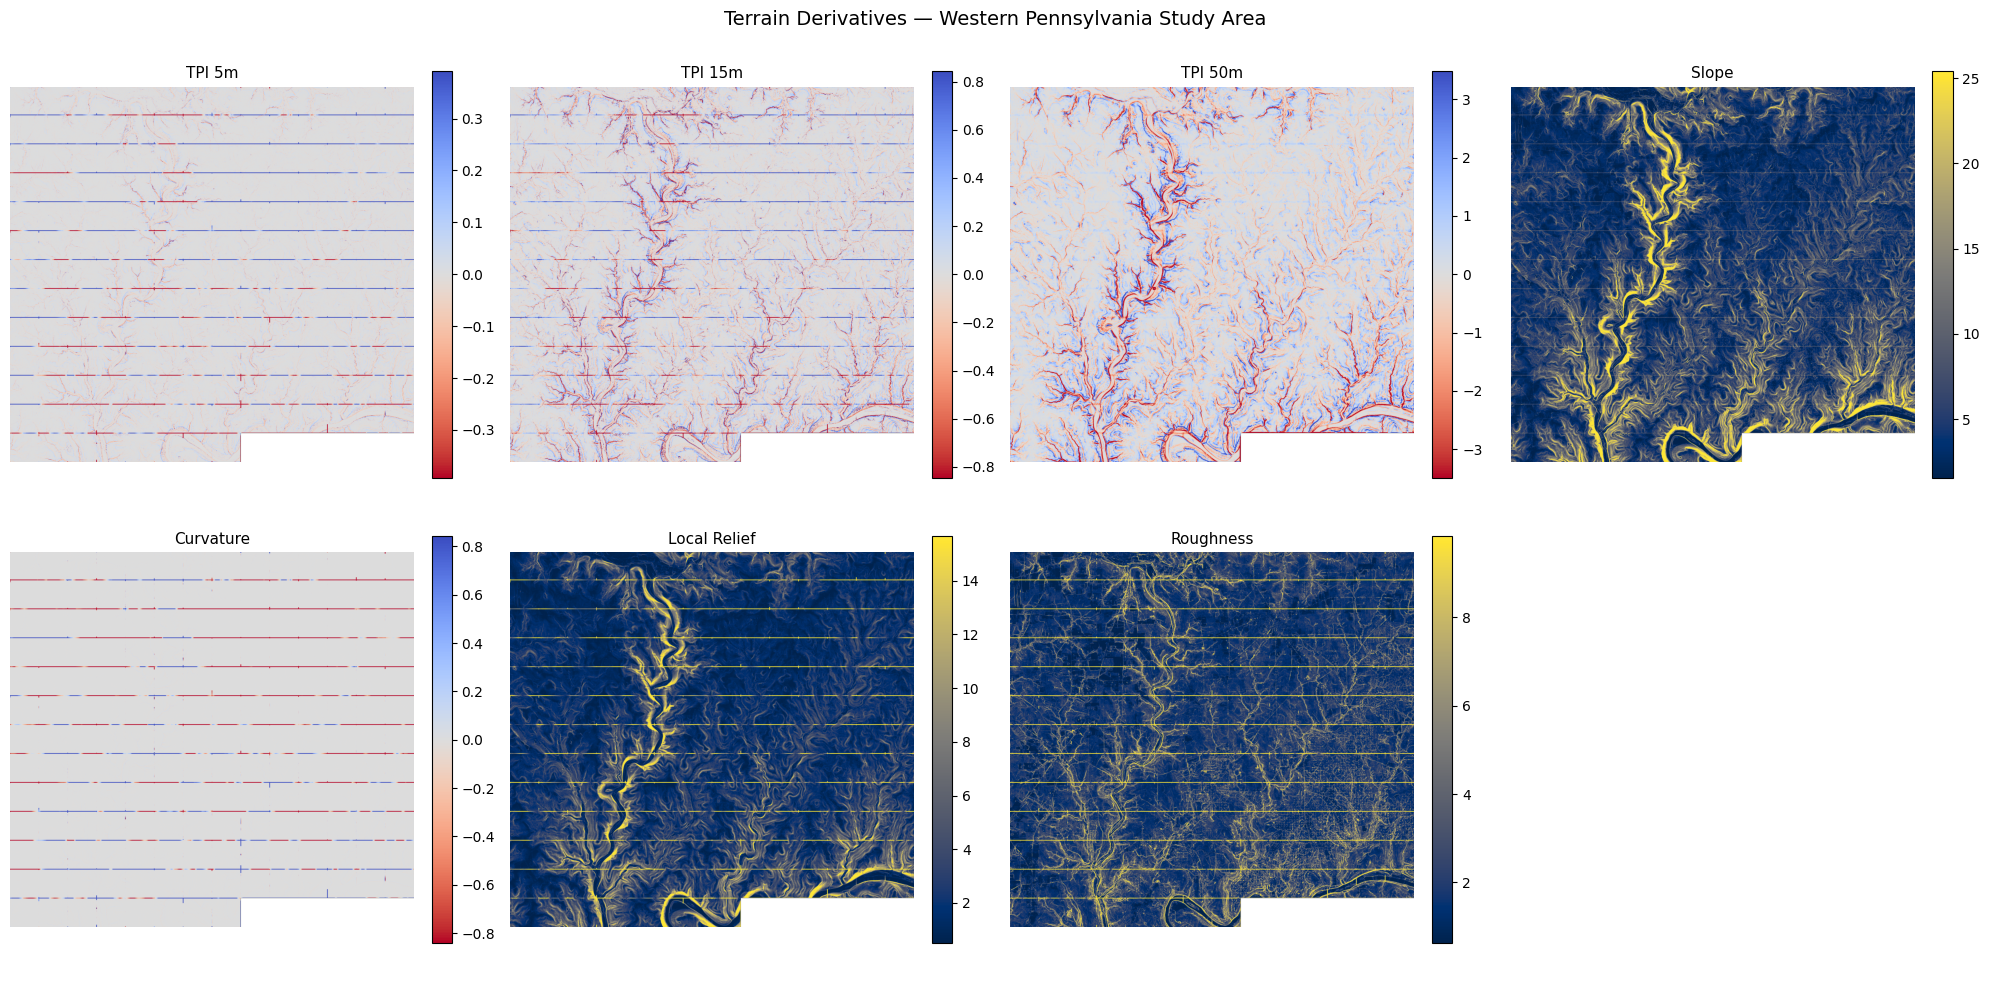

Saved → C:\users\colto\documents\github\lidar_project\data\derivatives_preview.png


In [10]:

# Visualise all seven terrain derivative layers.
# Colour conventions (CLAUDE.md):
#   Diverging data (TPI, curvature) — coolwarm_r, zero-centred:
#     blue = depression / concave,  warm = ridge / convex
#   Sequential data (slope, relief, roughness) — cividis
# The 2nd–98th percentile range is used for display to suppress outlier stretching.
#
# layers = {
#     'TPI 5m':       ('tpi_5m.tif',      'diverging'),
#     'TPI 15m':      ('tpi_15m.tif',     'diverging'),
#     'TPI 50m':      ('tpi_50m.tif',     'diverging'),
#     'Slope':        ('slope.tif',        'sequential'),
#     'Curvature':    ('curvature.tif',    'diverging'),
#     'Local Relief': ('relief_10m.tif',   'sequential'),
#     'Roughness':    ('roughness.tif',    'sequential'),
# }
#
# fig, axes = plt.subplots(2, 4, figsize=(20, 10))
# axes = axes.flatten()
#
# for idx, (title, (fname, kind)) in enumerate(layers.items()):
#     with rasterio.open(os.path.join(DERIV_FOLDER, fname)) as src:
#         data = src.read(1).astype('float32')
#         data[data == src.nodata] = np.nan
#
#     ax = axes[idx]
#
#     if kind == 'diverging':
#         absmax = np.nanpercentile(np.abs(data), 98)
#         norm   = TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
#         im     = ax.imshow(data, cmap='coolwarm_r', norm=norm)
#     else:
#         vmin, vmax = np.nanpercentile(data, [2, 98])
#         im         = ax.imshow(data, cmap='cividis', vmin=vmin, vmax=vmax)
#
#     ax.set_title(title, fontsize=11)
#     ax.axis('off')
#     plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#
# axes[-1].axis('off')  # hide the unused 8th subplot panel
# plt.suptitle('Terrain Derivatives — Western Pennsylvania Study Area', fontsize=14)
# plt.tight_layout()
#
# out_path = os.path.join(r'C:\users\colto\documents\github\lidar_project\data', 'derivatives_preview.png')
# plt.savefig(out_path, dpi=150, bbox_inches='tight')
# plt.show()
# print(f"Saved → {out_path}")
layers = {
    'TPI 5m':       ('tpi_5m.tif',      'diverging'),
    'TPI 15m':      ('tpi_15m.tif',     'diverging'),
    'TPI 50m':      ('tpi_50m.tif',     'diverging'),
    'Slope':        ('slope.tif',        'sequential'),
    'Curvature':    ('curvature.tif',    'diverging'),
    'Local Relief': ('relief_10m.tif',   'sequential'),
    'Roughness':    ('roughness.tif',    'sequential'),
}

# Read at 5% of full resolution — enough for visualization, tiny memory footprint
DISPLAY_SCALE = 0.05

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (title, (fname, kind)) in enumerate(layers.items()):
    with rasterio.open(os.path.join(DERIV_FOLDER, fname)) as src:
        out_h = max(1, int(src.height * DISPLAY_SCALE))
        out_w = max(1, int(src.width  * DISPLAY_SCALE))
        data  = src.read(
            1,
            out_shape=(1, out_h, out_w),
            resampling=rasterio.enums.Resampling.average
        ).astype('float32')
        data[data == src.nodata] = np.nan

    ax = axes[idx]

    if kind == 'diverging':
        absmax = np.nanpercentile(np.abs(data), 98)
        norm   = TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
        im     = ax.imshow(data, cmap='coolwarm_r', norm=norm)
    else:
        vmin, vmax = np.nanpercentile(data, [2, 98])
        im         = ax.imshow(data, cmap='cividis', vmin=vmin, vmax=vmax)

    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

axes[-1].axis('off')
plt.suptitle('Terrain Derivatives — Western Pennsylvania Study Area', fontsize=14)
plt.tight_layout()

out_path = os.path.join(r'C:\users\colto\documents\github\lidar_project\data', 'derivatives_preview.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

## Stage 4 — Well Data Integration

Combines two well datasets into a single point layer clipped to the LiDAR coverage extent.

| Dataset | Source | Count | Notes |
|---|---|---|---|
| PADEP Historic Oil and Gas Wells | WPA-era map digitisation | 30,527 | Positional accuracy ±10–100 m typical |
| USGS National Documented Orphan Wells | Federal agency compilation | ~79,000 filtered | Filtered to orphaned/abandoned `Status` codes only |

The USGS `Type` field is not used for filtering — it is inconsistently coded across contributing state agencies. `Status` is the reliable field.

In [11]:
# ── Source 1: PADEP Historic Oil and Gas Wells ────────────────────────────────
# Pennsylvania DEP shapefile derived from WPA-era hand-drawn maps (1930s).
# Covers Pennsylvania only. Positional accuracy is variable — many records are
# off by tens to hundreds of metres from the true well location.

wells_path = r'C:\Users\colto\Documents\PADEP_HistoricOilGasWells_ALL'
shp_file   = glob.glob(os.path.join(wells_path, '*.shp'))[0]
print(f"Loading shapefile: {shp_file}")

padep = gpd.read_file(shp_file)

# Standardise to a minimal schema and reproject to UTM Zone 17N to match the DEM
padep_slim = gpd.GeoDataFrame({
    'source':   'PADEP_historic',
    'state':    'Pennsylvania',
    'type':     padep['TYPE'],
    'geometry': padep['geometry']
}, crs=padep.crs).to_crs('EPSG:26917')

print(f"PADEP wells: {len(padep_slim)}")


# ── Source 2: USGS National Documented Orphan Wells ───────────────────────────
# Federal compilation of orphan well records from 27 states.
# Only records with orphaned or abandoned Status codes are retained.
# The Type field is intentionally excluded from filtering — it is inconsistently
# coded across contributing state agencies; Status is the reliable field.

csv_path = r'C:\sp\US_orphaned_wells.csv'
print(f"\nLoading CSV: {csv_path}")

usgs = pd.read_csv(csv_path, low_memory=False)

# Status codes that identify orphaned or abandoned wells
target_statuses = [
    'Orphan', 'orphan', 'Orphaned',
    'OR',
    'Abandoned', 'Abandoned Well', 'Abandoned Orphaned Well',
    'ACT 404 ORPHAN WELL-ENG',
    'ACT 404 ORPHAN WELL-INJECTION AND MINING'
]
usgs = usgs[usgs['Status'].isin(target_statuses)].copy()

# Remove rows that lack coordinates — they cannot be placed on the map
usgs = usgs.dropna(subset=['Latitude', 'Longitude'])

# Build a GeoDataFrame from lat/lon columns, then reproject to match the DEM CRS
usgs_gdf = gpd.GeoDataFrame(
    {
        'source':   'USGS_national',
        'state':    usgs['State'],
        'type':     usgs['Type'],
        'geometry': [Point(xy) for xy in zip(usgs['Longitude'], usgs['Latitude'])]
    },
    crs='EPSG:4326'   # input coordinates are WGS84 geographic
).to_crs('EPSG:26917')

print(f"USGS orphaned wells (filtered): {len(usgs_gdf)}")
print(f"States represented: {usgs_gdf['state'].nunique()}")


# ── Merge both sources ────────────────────────────────────────────────────────
wells = pd.concat([padep_slim, usgs_gdf], ignore_index=True)
wells = gpd.GeoDataFrame(wells, crs='EPSG:26917')

print(f"\nCombined total: {len(wells)}")
print(f"\nBy source:")
print(wells['source'].value_counts())

Loading shapefile: C:\Users\colto\Documents\PADEP_HistoricOilGasWells_ALL\PADEP_HistoricOilGasWells_ALL.shp
PADEP wells: 30527

Loading CSV: C:\sp\US_orphaned_wells.csv
USGS orphaned wells (filtered): 79456
States represented: 16

Combined total: 109983

By source:
source
USGS_national     79456
PADEP_historic    30527
Name: count, dtype: int64


In [12]:
print("Well types:")
print(wells['type'].value_counts().head(20))

# Confirm the combined dataset is in the correct projected CRS before any
# spatial operations — all subsequent geometry work assumes EPSG:26917
wells_utm = wells.copy()
print(f"\nCRS: {wells_utm.crs}")

# Build a bounding-box polygon from the DEM's spatial extent.
# Wells outside this extent have no LiDAR coverage and cannot contribute
# terrain features, so they are removed from training data.
with rasterio.open(FULL_DEM) as src:
    dem_bounds = src.bounds
    dem_crs    = src.crs

dem_bbox = box(dem_bounds.left, dem_bounds.bottom, dem_bounds.right, dem_bounds.top)
dem_gdf  = gpd.GeoDataFrame(geometry=[dem_bbox], crs=dem_crs)

# Spatial clip — drops all wells that fall outside the LiDAR tile footprint
wells_clipped = gpd.clip(wells_utm, dem_gdf)

# Reset index after clip so that positional indexing into well_df and
# wells_clipped stays aligned in the feature extraction cells below.
# Without this reset, the type column comes out all-NaN in well_df.
wells_clipped = wells_clipped.reset_index(drop=True)

print(f"\nWells in full dataset:      {len(wells_utm)}")
print(f"Wells inside LiDAR extent:  {len(wells_clipped)}")
print(f"\nBy source in clipped area:")
print(wells_clipped['source'].value_counts())

Well types:
type
Oil Well                         13180
Gas Well                          9796
OIL                               8726
O                                 5365
GAS                               4890
Dry Hole                          3964
Well, No Record                   3189
WI                                2448
NT                                2444
Vertical                          2140
Not Available                     1454
DRY                               1294
Abandoned Gas Well                1147
Gas(Convertional, Commercial)     1055
Stratigraphic Test                1042
NO PRODUCT SPECIFIED              1019
OG                                1004
TM                                 958
CBM Well                           934
Oil                                707
Name: count, dtype: int64

CRS: EPSG:26917

Wells in full dataset:      109983
Wells inside LiDAR extent:  3426

By source in clipped area:
source
USGS_national    3426
Name: count, dtype: int64


In [13]:
# Pre-extraction gate — confirm there are enough wells to proceed.
# A clipped count of zero almost always means a CRS mismatch between the
# well dataset and the DEM; both should be EPSG:26917 at this point.
n = len(wells_clipped)

if n == 0:
    raise RuntimeError(
        "No wells fall within the LiDAR extent. "
        "Check that both the DEM and well GeoDataFrame are in EPSG:26917."
    )
elif n < 100:
    print(f"WARNING: only {n} wells inside extent — classifier will have very limited training data.")
else:
    print(f"OK — {n} wells available for feature extraction.")

# Fraction of the total dataset that falls within coverage
pct = n / len(wells_utm) * 100
print(f"Coverage: {n} of {len(wells_utm)} total wells ({pct:.1f}%)")

OK — 3426 wells available for feature extraction.
Coverage: 3426 of 109983 total wells (3.1%)


## Stage 5 — Feature Extraction

Extracts terrain derivative values at well locations and at an equal number of randomly generated background points (balanced 1:1 class ratio).

Two extraction modes are computed and stored separately:

| Variable | Method | Features | Notes |
|---|---|---|---|
| `all_samples` | Point — single pixel at coordinate | 7 | Fast; sensitive to positional error in historic records |
| `all_patch` | Patch — mean, min, std over 15 m buffer | 21 | Preferred; compensates for coordinate offsets up to ~30–100 m |

Select which to use for classification with `FEATURE_SET` in Stage 6.

In [14]:
# Map each derivative name to its raster file path.
# This dictionary is reused in point extraction, patch extraction, and the
# feature column selection in the classifier.
rasters = {
    'tpi_5m':    os.path.join(DERIV_FOLDER, 'tpi_5m.tif'),
    'tpi_15m':   os.path.join(DERIV_FOLDER, 'tpi_15m.tif'),
    'tpi_50m':   os.path.join(DERIV_FOLDER, 'tpi_50m.tif'),
    'slope':     os.path.join(DERIV_FOLDER, 'slope.tif'),
    'curvature': os.path.join(DERIV_FOLDER, 'curvature.tif'),
    'relief':    os.path.join(DERIV_FOLDER, 'relief_10m.tif'),
    'roughness': os.path.join(DERIV_FOLDER, 'roughness.tif'),
}

# Extract the single raster pixel value at each well coordinate.
# point_query returns None for coordinates on nodata pixels or outside the
# raster extent — these become NaN in the DataFrame and are dropped later.
print("Extracting point features at well locations...")
well_features = {}
for name, path in rasters.items():
    well_features[name] = point_query(wells_clipped, path)

well_df          = pd.DataFrame(well_features)
well_df['label'] = 1                            # 1 = confirmed well
well_df['type']  = wells_clipped['type'].values

print(f"Well samples: {len(well_df)}")
print(f"NaN count per feature:")
print(well_df.drop(columns=['label', 'type']).isna().sum())
print(f"\nSample:")
print(well_df.head())

Extracting point features at well locations...
Well samples: 3426
NaN count per feature:
tpi_5m       37
tpi_15m      37
tpi_50m      37
slope        37
curvature    37
relief       37
roughness    37
dtype: int64

Sample:
     tpi_5m   tpi_15m   tpi_50m     slope  curvature    relief  roughness  \
0       NaN       NaN       NaN       NaN        NaN       NaN        NaN   
1       NaN       NaN       NaN       NaN        NaN       NaN        NaN   
2 -0.058247 -0.140096  1.198271  5.889596   0.100206  3.386711   1.102475   
3  0.081193  0.184802  0.246708  2.991245  -0.130112  2.738085   1.398322   
4       NaN       NaN       NaN       NaN        NaN       NaN        NaN   

   label type  
0      1  NaN  
1      1  NaN  
2      1  NaN  
3      1  NaN  
4      1  NaN  


### Negative Sampling

Generates an equal number of random background points within the LiDAR coverage extent to serve as non-well (label = 0) training examples. Each candidate point is rejected if it falls within a 50 m buffer around any known well location or outside valid DEM data.

In [15]:
# Drop wells that landed on nodata pixels — they contribute no usable features
well_df_clean = well_df.dropna(subset=list(rasters.keys())).reset_index(drop=True)
print(f"Usable well samples (after NaN drop): {len(well_df_clean)}")

# Load DEM spatial metadata needed to validate random candidate points
with rasterio.open(FULL_DEM) as src:
    bounds    = src.bounds
    dem_arr   = src.read(1)
    nodata_v  = src.nodata
    transform = src.transform

# Boolean array — True where the DEM has valid elevation data
valid_mask_flat = dem_arr != nodata_v

# Union of 50 m buffers around all known wells.
# Random candidate points inside this exclusion zone are rejected to avoid
# accidentally labelling a well site as a background (non-well) sample.
all_well_buffer = wells_clipped.geometry.buffer(50).union_all()

# Rejection sampling: draw random (x, y) within the DEM bounding box and
# accept a point only if it is (a) outside all well buffers and
# (b) on a valid DEM pixel. Repeat until the negative set matches the positive set.
random.seed(42)
non_well_points = []
attempts        = 0
max_attempts    = 200_000

while len(non_well_points) < len(well_df_clean) and attempts < max_attempts:
    x  = random.uniform(bounds.left,   bounds.right)
    y  = random.uniform(bounds.bottom, bounds.top)
    pt = Point(x, y)

    if not all_well_buffer.contains(pt):
        # Convert geographic coordinates to pixel row/column indices
        col, row = ~transform * (x, y)
        col, row = int(col), int(row)
        if 0 <= row < dem_arr.shape[0] and 0 <= col < dem_arr.shape[1]:
            if valid_mask_flat[row, col]:
                non_well_points.append(pt)
    attempts += 1

print(f"Generated {len(non_well_points)} negative samples ({attempts} attempts)")

# Build a GeoDataFrame so rasterstats can extract features at these locations
non_wells_gdf = gpd.GeoDataFrame(geometry=non_well_points, crs=wells_clipped.crs)

# Extract the same seven point features at the background locations
print("Extracting point features at non-well locations...")
nonwell_features = {}
for name, path in rasters.items():
    nonwell_features[name] = point_query(non_wells_gdf, path)

nonwell_df          = pd.DataFrame(nonwell_features)
nonwell_df['label'] = 0              # 0 = background (non-well)
nonwell_df['type']  = 'non_well'
nonwell_df          = nonwell_df.dropna().reset_index(drop=True)

# Combine well and non-well point samples into the balanced point-feature dataset
all_samples = pd.concat([well_df_clean, nonwell_df], ignore_index=True)
print(f"\nFinal dataset:")
print(f"  Wells (label=1):     {(all_samples['label']==1).sum()}")
print(f"  Non-wells (label=0): {(all_samples['label']==0).sum()}")
print(f"  Total:               {len(all_samples)}")

Usable well samples (after NaN drop): 3389
Generated 3389 negative samples (3732 attempts)
Extracting point features at non-well locations...

Final dataset:
  Wells (label=1):     3389
  Non-wells (label=0): 3389
  Total:               6778


In [16]:
def extract_patch_features(gdf, rasters, radius_m=15):
    """Extract summary statistics over a circular buffer around each point.

    For each point in gdf, a disc of radius_m metres is buffered and
    zonal_stats computes the mean, minimum, and standard deviation of each
    derivative layer within that disc.

    Returns a DataFrame with columns {name}_mean, {name}_min, {name}_std
    for every layer in rasters.

    Using patch statistics rather than single-pixel values compensates for the
    30–100 m positional uncertainty typical of WPA-era well records: even if
    the recorded coordinate is off, the correct terrain signature is likely
    captured somewhere within the 15 m buffer.
    """
    buffered             = gdf.copy()
    buffered['geometry'] = gdf.geometry.buffer(radius_m)

    all_features = {}
    for name, path in rasters.items():
        stats = zonal_stats(buffered, path, stats=['mean', 'min', 'std'], nodata=np.nan)
        all_features[f'{name}_mean'] = [s['mean'] for s in stats]
        all_features[f'{name}_min']  = [s['min']  for s in stats]
        all_features[f'{name}_std']  = [s['std']  for s in stats]

    return pd.DataFrame(all_features)


# Extract patch features at known well locations (label = 1)
print("Extracting patch features at well locations...")
well_patch_df          = extract_patch_features(wells_clipped, rasters, radius_m=15)
well_patch_df['label'] = 1
well_patch_df['type']  = wells_clipped['type'].values

# Extract patch features at background locations (label = 0)
print("Extracting patch features at non-well locations...")
nonwell_patch_df          = extract_patch_features(non_wells_gdf, rasters, radius_m=15)
nonwell_patch_df['label'] = 0
nonwell_patch_df['type']  = 'non_well'

# Combine and drop rows where all stats are NaN (points outside raster extent)
all_patch = pd.concat([well_patch_df, nonwell_patch_df], ignore_index=True)
all_patch = all_patch.dropna().reset_index(drop=True)

print(f"\nFinal patch dataset:")
print(f"  Wells:     {(all_patch['label']==1).sum()}")
print(f"  Non-wells: {(all_patch['label']==0).sum()}")
print(f"  Features:  {[c for c in all_patch.columns if c not in ['label', 'type']]}")

Extracting patch features at well locations...
Extracting patch features at non-well locations...

Final patch dataset:
  Wells:     0
  Non-wells: 3389
  Features:  ['tpi_5m_mean', 'tpi_5m_min', 'tpi_5m_std', 'tpi_15m_mean', 'tpi_15m_min', 'tpi_15m_std', 'tpi_50m_mean', 'tpi_50m_min', 'tpi_50m_std', 'slope_mean', 'slope_min', 'slope_std', 'curvature_mean', 'curvature_min', 'curvature_std', 'relief_mean', 'relief_min', 'relief_std', 'roughness_mean', 'roughness_min', 'roughness_std']


## Stage 6 — Classification

Trains a binary classifier (well vs. non-well) on the extracted terrain features and evaluates on a held-out 30% test split.

**To switch models or feature sets**, change the variables in the configuration cell below and re-run that cell plus the one after it — no other cells need to change.

| `CLASSIFIER` | Algorithm | Notes |
|---|---|---|
| `'random_forest'` | Random Forest (200 trees) | Interpretable baseline; feature importances are directly meaningful |
| `'xgboost'` | XGBoost (200 rounds) | Sequential gradient boosting; typically stronger on tabular data |
| `'neural_network'` | MLP (64→32, ReLU) | Feedforward network; features are standardised automatically |

| `FEATURE_SET` | Dataset | Features |
|---|---|---|
| `'point'` | `all_samples` | 7 |
| `'patch'` | `all_patch` | 21 |

In [17]:
# ── CLASSIFIER CONFIGURATION ─────────────────────────────────────────────────
# Change CLASSIFIER and re-run this cell + the next one to switch models.

CLASSIFIER  = 'random_forest'   # 'random_forest' | 'xgboost' | 'neural_network'
FEATURE_SET = 'point'           # 'point'  — 7 point-sampled features
                                # 'patch'  — 21 patch stats (requires all_patch)

Classifier:  random_forest
Features:    point  (7)
Train: 4744  |  Test: 2034

--- RANDOM_FOREST  |  point features ---
              precision    recall  f1-score   support

    non-well       0.57      0.59      0.58      1017
        well       0.58      0.55      0.56      1017

    accuracy                           0.57      2034
   macro avg       0.57      0.57      0.57      2034
weighted avg       0.57      0.57      0.57      2034



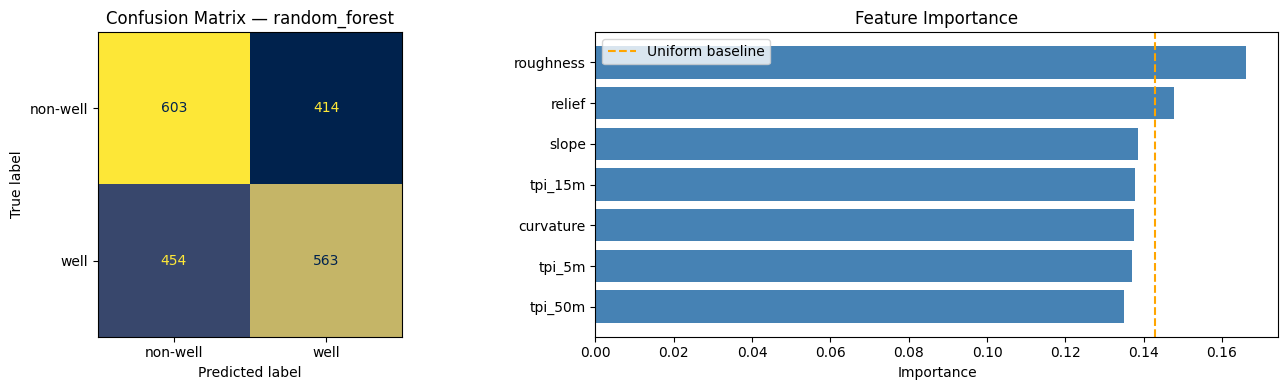

Saved → C:\users\colto\documents\github\lidar_project\data\model_results_random_forest.png


In [18]:
# ── Feature preparation ───────────────────────────────────────────────────────
# Select the dataset and feature column list based on FEATURE_SET:
#   'point' — 7 raw values sampled at the well coordinate (all_samples)
#   'patch' — 21 patch statistics (mean/min/std × 7 layers) over a 15 m buffer (all_patch)

if FEATURE_SET == 'patch':
    dataset      = all_patch
    feature_cols = [c for c in all_patch.columns if c not in ['label', 'type']]
else:
    dataset      = all_samples
    feature_cols = ['tpi_5m', 'tpi_15m', 'tpi_50m', 'slope', 'curvature', 'relief', 'roughness']

X = dataset[feature_cols]
y = dataset['label']

# Stratified split preserves the 50/50 class balance in both partitions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Classifier:  {CLASSIFIER}")
print(f"Features:    {FEATURE_SET}  ({len(feature_cols)})")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")


# ── Feature scaling ────────────────────────────────────────────────────────────
# Tree-based models (RF, XGBoost) are scale-invariant — no scaling needed.
# Neural networks are sensitive to input scale — StandardScaler is required.
# Scaling is fit on the training set only to avoid data leakage into the test set.

if CLASSIFIER == 'neural_network':
    scaler      = StandardScaler()
    X_train_fit = scaler.fit_transform(X_train)
    X_test_fit  = scaler.transform(X_test)
else:
    X_train_fit = X_train
    X_test_fit  = X_test


# ── Model factory ─────────────────────────────────────────────────────────────
def build_model(name):
    """Instantiate and return the classifier specified by name.

    random_forest  — 200 trees, all cores. Interpretable via feature_importances_.

    xgboost        — 200 boosting rounds, lr=0.1, max_depth=6.
                     subsample=0.8 and colsample_bytree=0.8 add stochastic
                     regularisation that reduces overfitting on the relatively
                     small tabular feature set.

    neural_network — Two hidden layers (64 → 32 units), ReLU activation, Adam
                     optimiser. early_stopping=True halts training when validation
                     loss stops improving. Expects standardised input — handled
                     above before this function is called.
    """
    if name == 'random_forest':
        return RandomForestClassifier(
            n_estimators=200, random_state=42, n_jobs=-1
        )
    if name == 'xgboost':
        return XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,          # row subsampling fraction per tree
            colsample_bytree=0.8,   # feature subsampling fraction per tree
            random_state=42,
            n_jobs=-1
        )
    if name == 'neural_network':
        return MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            max_iter=500,
            early_stopping=True,    # holds out 10% of training data as validation set
            random_state=42
        )
    raise ValueError(f"Unknown classifier: {name!r}")


model = build_model(CLASSIFIER)
model.fit(X_train_fit, y_train)


# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test_fit)

print(f"\n--- {CLASSIFIER.upper()}  |  {FEATURE_SET} features ---")
print(classification_report(y_test, y_pred, target_names=['non-well', 'well']))


# ── Results visualisation ─────────────────────────────────────────────────────
# Left panel:  confusion matrix (rows = true label, columns = predicted label)
# Right panel: feature importance — mean decrease in impurity for Random Forest;
#              cumulative gain across trees for XGBoost. The orange dashed line
#              marks the uniform-random baseline (1 / n_features).
#              MLPClassifier does not expose feature importances — only the
#              confusion matrix is shown in that case.

has_importances = hasattr(model, 'feature_importances_')
ncols = 2 if has_importances else 1
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols + 2, 4))
if ncols == 1:
    axes = [axes]

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['non-well', 'well'])
disp.plot(ax=axes[0], colorbar=False, cmap='cividis')
axes[0].set_title(f'Confusion Matrix — {CLASSIFIER}')

if has_importances:
    imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
    axes[1].barh(imp.index, imp.values, color='steelblue')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Feature Importance')
    axes[1].axvline(1 / len(feature_cols), color='orange', linestyle='--', label='Uniform baseline')
    axes[1].legend()

plt.tight_layout()
out_path = os.path.join(r'C:\users\colto\documents\github\lidar_project\data',
                        f'model_results_{CLASSIFIER}.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

In [19]:
# Attach terrain feature values back to the clipped wells GeoDataFrame so that
# results can be inspected spatially in GIS software (QGIS, ArcGIS, etc.).
#
# Always export the 7 point features regardless of what FEATURE_SET is set to.
# If FEATURE_SET is 'patch', feature_cols holds 21 patch-stat column names that
# do not exist in well_df, which would cause a KeyError or shape mismatch.
# The point features in well_df are always available and align 1-to-1 with
# the clipped well geometry rows.
#
# well_df (not well_df_clean) is used to preserve the full row count —
# wells on nodata pixels get NaN feature values rather than being dropped.

point_cols   = ['tpi_5m', 'tpi_15m', 'tpi_50m', 'slope', 'curvature', 'relief', 'roughness']
wells_export = wells_clipped.copy().reset_index(drop=True)

for col in point_cols:
    wells_export[col] = well_df[col].values

wells_export.to_file(r'C:\users\colto\documents\github\lidar_project\data\wells_with_features.shp')
print("Exported.")
print(f"Total rows:               {len(wells_export)}")
print(f"Rows with valid features: {wells_export['tpi_5m'].notna().sum()}")

Exported.
Total rows:               3426
Rows with valid features: 3389


In [20]:
import geopandas as gpd

dep_wells = gpd.read_file(r'C:\sp\OilGasLocations_ConventionalUnconventional2025_12.shp')
print(f"Total DEP wells: {len(dep_wells)}")
print(f"\nColumns: {list(dep_wells.columns)}")
print(f"\nSample rows:")
print(dep_wells.head(3).to_string())

Total DEP wells: 223281

Columns: ['PERMIT_NUM', 'WELL_NAME', 'OPERATOR', 'OPERATOR_N', 'WELL_TYPE', 'WELL_TYPE_', 'WELL_STATU', 'WELL_STA_1', 'PERMIT_DAT', 'SPUD_DATE', 'CONSERVATI', 'COUNTY', 'COUNTY_ID', 'MUNICIPALI', 'MUNICIPA_1', 'MUNICIPA_2', 'LATITUDE', 'LONGITUDE', 'PRMRY_FID', 'UNCONVENTI', 'SURFACE_EL', 'WELL_CONFI', 'COAL_IND', 'WELL_PAD_N', 'OLDEST_FOR', 'TARGET_FOR', 'PRODUCING_', 'WELL_PAD_L', 'ACCESS_ROA', 'TOTAL_MAXI', 'REACH_CODE', 'HUC_CODE', 'REGION', 'DATE_PLUGG', 'WELL_PAD_I', 'UIC_ID', 'UIC_TYPE_D', 'STORAGE_FI', 'SITE_ID', 'SITE_NAME', 'PERMIT_D_1', 'geometry']

Sample rows:
  PERMIT_NUM                             WELL_NAME                   OPERATOR OPERATOR_N WELL_TYPE WELL_TYPE_       WELL_STATU WELL_STA_1 PERMIT_DAT  SPUD_DATE CONSERVATI     COUNTY  COUNTY_ID   MUNICIPALI MUNICIPA_1 MUNICIPA_2   LATITUDE  LONGITUDE  PRMRY_FID UNCONVENTI  SURFACE_EL     WELL_CONFI COAL_IND WELL_PAD_N OLDEST_FOR TARGET_FOR PRODUCING_ WELL_PAD_L ACCESS_ROA TOTAL_MAXI REACH_CODE

In [23]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from rasterstats import point_query, zonal_stats
from scipy import stats
from scipy.ndimage import uniform_filter, maximum_filter, minimum_filter
from shapely.geometry import Point
import os, glob, warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
NLCD_PATH   = r'C:\sp\Annual_NLCD_LndCov_2024_CU_C1V1_c37a1cb6-bb15-49cb-afa4-5f037356b6d3.tiff'
DEP_PATH    = r'C:\sp\OilGasLocations_ConventionalUnconventional2025_12.shp'
DERIV_FOLDER = r'C:\users\colto\documents\github\lidar_project\data\derivatives'
FULL_DEM     = r'C:\Users\colto\Documents\GitHub\lidar_project\data\full_dem.tif'

RASTERS = {
    'tpi_5m':    os.path.join(DERIV_FOLDER, 'tpi_5m.tif'),
    'tpi_15m':   os.path.join(DERIV_FOLDER, 'tpi_15m.tif'),
    'tpi_50m':   os.path.join(DERIV_FOLDER, 'tpi_50m.tif'),
    'slope':     os.path.join(DERIV_FOLDER, 'slope.tif'),
    'curvature': os.path.join(DERIV_FOLDER, 'curvature.tif'),
    'relief':    os.path.join(DERIV_FOLDER, 'relief_10m.tif'),
    'roughness': os.path.join(DERIV_FOLDER, 'roughness.tif'),
}

# NLCD class code → readable label
NLCD_CLASSES = {
    11: 'Open Water', 21: 'Developed Open', 22: 'Developed Low',
    23: 'Developed Med', 24: 'Developed High', 31: 'Barren',
    41: 'Deciduous Forest', 42: 'Evergreen Forest', 43: 'Mixed Forest',
    52: 'Shrub/Scrub', 71: 'Grassland', 81: 'Pasture/Hay',
    82: 'Cultivated Crops', 90: 'Woody Wetlands', 95: 'Emergent Wetlands'
}

print("Setup complete.")

Setup complete.


In [25]:
# ── Load DEP current wells — source of spud dates ────────────────────────────
print("Loading DEP current wells...")
dep = gpd.read_file(DEP_PATH)
dep = dep.to_crs('EPSG:26917')

# Parse SPUD_DATE, replace 1800-01-01 placeholder with NaT
dep['SPUD_DATE'] = pd.to_datetime(dep['SPUD_DATE'], errors='coerce')
dep.loc[dep['SPUD_DATE'].dt.year < 1850, 'SPUD_DATE'] = pd.NaT
dep['spud_year'] = dep['SPUD_DATE'].dt.year
print(f"DEP wells with valid spud date: {dep['spud_year'].notna().sum():,}")

# ── Clip DEP wells to LiDAR extent ───────────────────────────────────────────
with rasterio.open(FULL_DEM) as src:
    dem_bounds = src.bounds

from shapely.geometry import box
dem_box  = box(dem_bounds.left, dem_bounds.bottom, dem_bounds.right, dem_bounds.top)
dem_gdf  = gpd.GeoDataFrame(geometry=[dem_box], crs='EPSG:26917')
dep_clip = gpd.clip(dep, dem_gdf).reset_index(drop=True)
print(f"DEP wells inside LiDAR extent: {len(dep_clip)}")

# ── Spatial join: nearest DEP well to each historic well ─────────────────────
# For each PADEP/USGS well, find the closest DEP well within 150m
# and inherit its spud year as an age proxy
print("Joining age from nearest DEP well (within 150m)...")

wells_for_age = wells_clipped.copy().reset_index(drop=True)

# sjoin_nearest finds closest match; max_distance limits to 150m
age_join = gpd.sjoin_nearest(
    wells_for_age[['geometry']],
    dep_clip[['geometry', 'spud_year', 'WELL_TYPE', 'WELL_STATU', 'DATE_PLUGG']],
    how='left',
    max_distance=150,
    distance_col='match_dist_m'
)

# Keep only the first match per well (sjoin_nearest can return duplicates)
age_join = age_join[~age_join.index.duplicated(keep='first')]

wells_for_age['spud_year']    = age_join['spud_year'].values
wells_for_age['match_dist_m'] = age_join['match_dist_m'].values
wells_for_age['dep_status']   = age_join['WELL_STATU'].values
wells_for_age['date_plugged'] = pd.to_datetime(age_join['DATE_PLUGG'].values, errors='coerce')

# Decade bins for grouping
wells_for_age['decade'] = (wells_for_age['spud_year'] // 10 * 10).astype('Int64')

matched = wells_for_age['spud_year'].notna().sum()
print(f"Wells matched to a DEP record: {matched} / {len(wells_for_age)}")
print(f"\nDecade distribution of matched wells:")
print(wells_for_age['decade'].value_counts().sort_index())

Loading DEP current wells...
DEP wells with valid spud date: 115,577
DEP wells inside LiDAR extent: 11295
Joining age from nearest DEP well (within 150m)...
Wells matched to a DEP record: 2365 / 3426

Decade distribution of matched wells:
decade
1940       1
1950      11
1960     113
1970     953
1980    1147
1990      79
2000      38
2010      23
Name: count, dtype: Int64


In [26]:
# ── Extract NLCD land cover at each well ─────────────────────────────────────
print("Extracting NLCD land cover...")

# NLCD is in Albers (EPSG:5070) — reproject wells to match
wells_albers = wells_for_age.to_crs('EPSG:5070')
nlcd_vals    = point_query(wells_albers, NLCD_PATH, interpolate='nearest')
wells_for_age['nlcd_code']  = [int(v) if v is not None else None for v in nlcd_vals]
wells_for_age['nlcd_label'] = wells_for_age['nlcd_code'].map(NLCD_CLASSES).fillna('Unknown')

print(f"\nLand cover distribution at well locations:")
print(wells_for_age['nlcd_label'].value_counts())

# ── Derive terrain classes from existing derivatives ─────────────────────────
print("\nExtracting terrain features at well locations...")

features = {}
for name, path in RASTERS.items():
    features[name] = point_query(wells_for_age, path)

feat_df = pd.DataFrame(features)
wells_for_age = pd.concat([wells_for_age.reset_index(drop=True), feat_df], axis=1)

# Classify slope into terrain context bins
wells_for_age['slope_class'] = pd.cut(
    wells_for_age['slope'],
    bins=[0, 5, 15, 30, 90],
    labels=['Flat (0-5°)', 'Gentle (5-15°)', 'Moderate (15-30°)', 'Steep (>30°)']
)

# Classify local relief into bins
wells_for_age['relief_class'] = pd.cut(
    wells_for_age['relief'],
    bins=[0, 2, 5, 10, 100],
    labels=['Very Low (<2m)', 'Low (2-5m)', 'Moderate (5-10m)', 'High (>10m)']
)

# Drop rows with no terrain features
wells_enriched = wells_for_age.dropna(subset=list(RASTERS.keys())).reset_index(drop=True)
print(f"\nWells with full terrain features: {len(wells_enriched)}")
print(wells_enriched[['type','nlcd_label','slope_class','relief_class','decade']].describe())

Extracting NLCD land cover...

Land cover distribution at well locations:
nlcd_label
Deciduous Forest    3074
Mixed Forest         129
Developed Open        89
Pasture/Hay           56
Woody Wetlands        47
Grassland             11
Shrub/Scrub            9
Developed Low          5
Evergreen Forest       2
Barren                 2
Developed Med          1
Open Water             1
Name: count, dtype: int64

Extracting terrain features at well locations...

Wells with full terrain features: 3389
            decade
count       2337.0
mean   1975.840822
std       8.102849
min         1940.0
25%         1970.0
50%         1980.0
75%         1980.0
max         2010.0


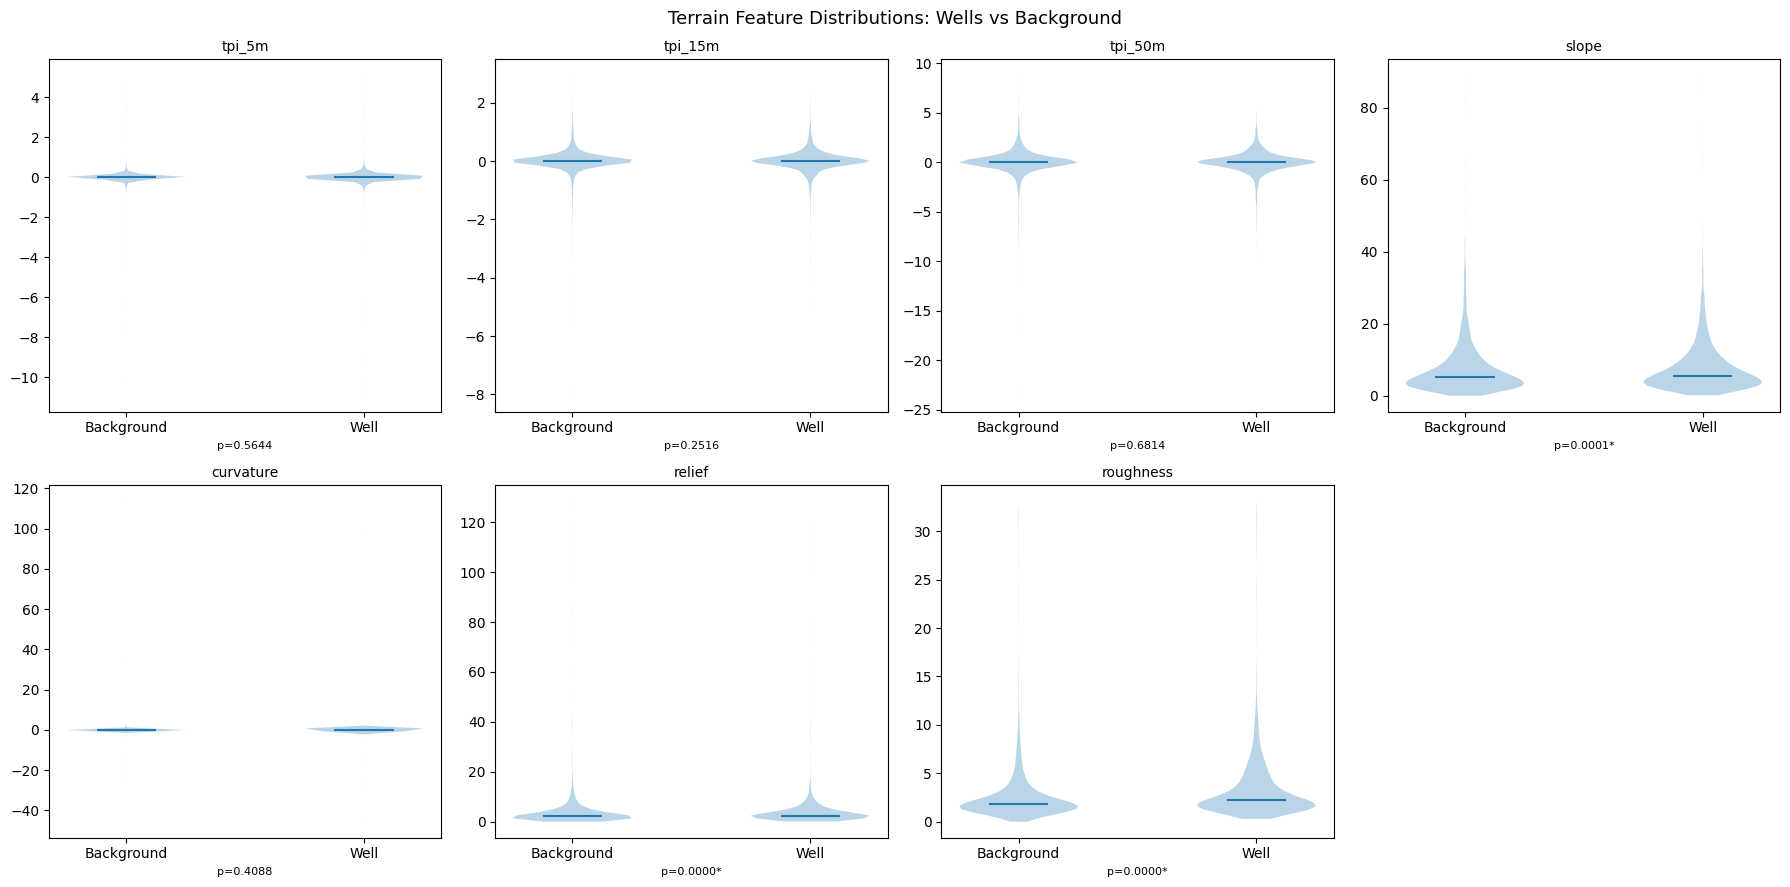

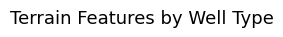

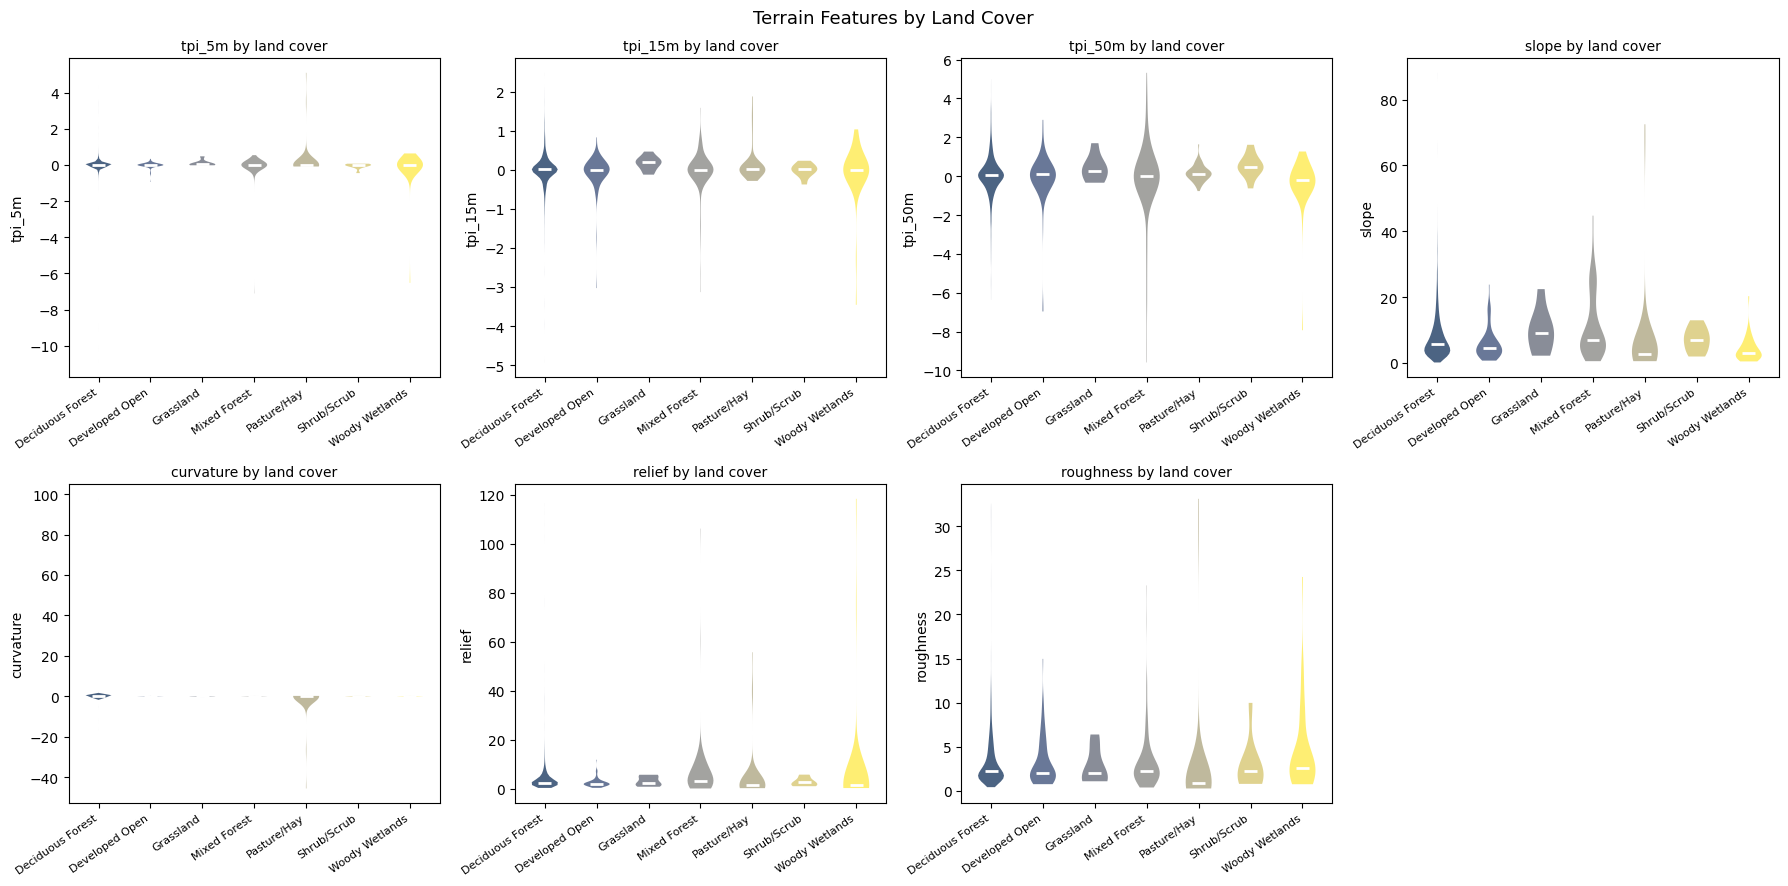

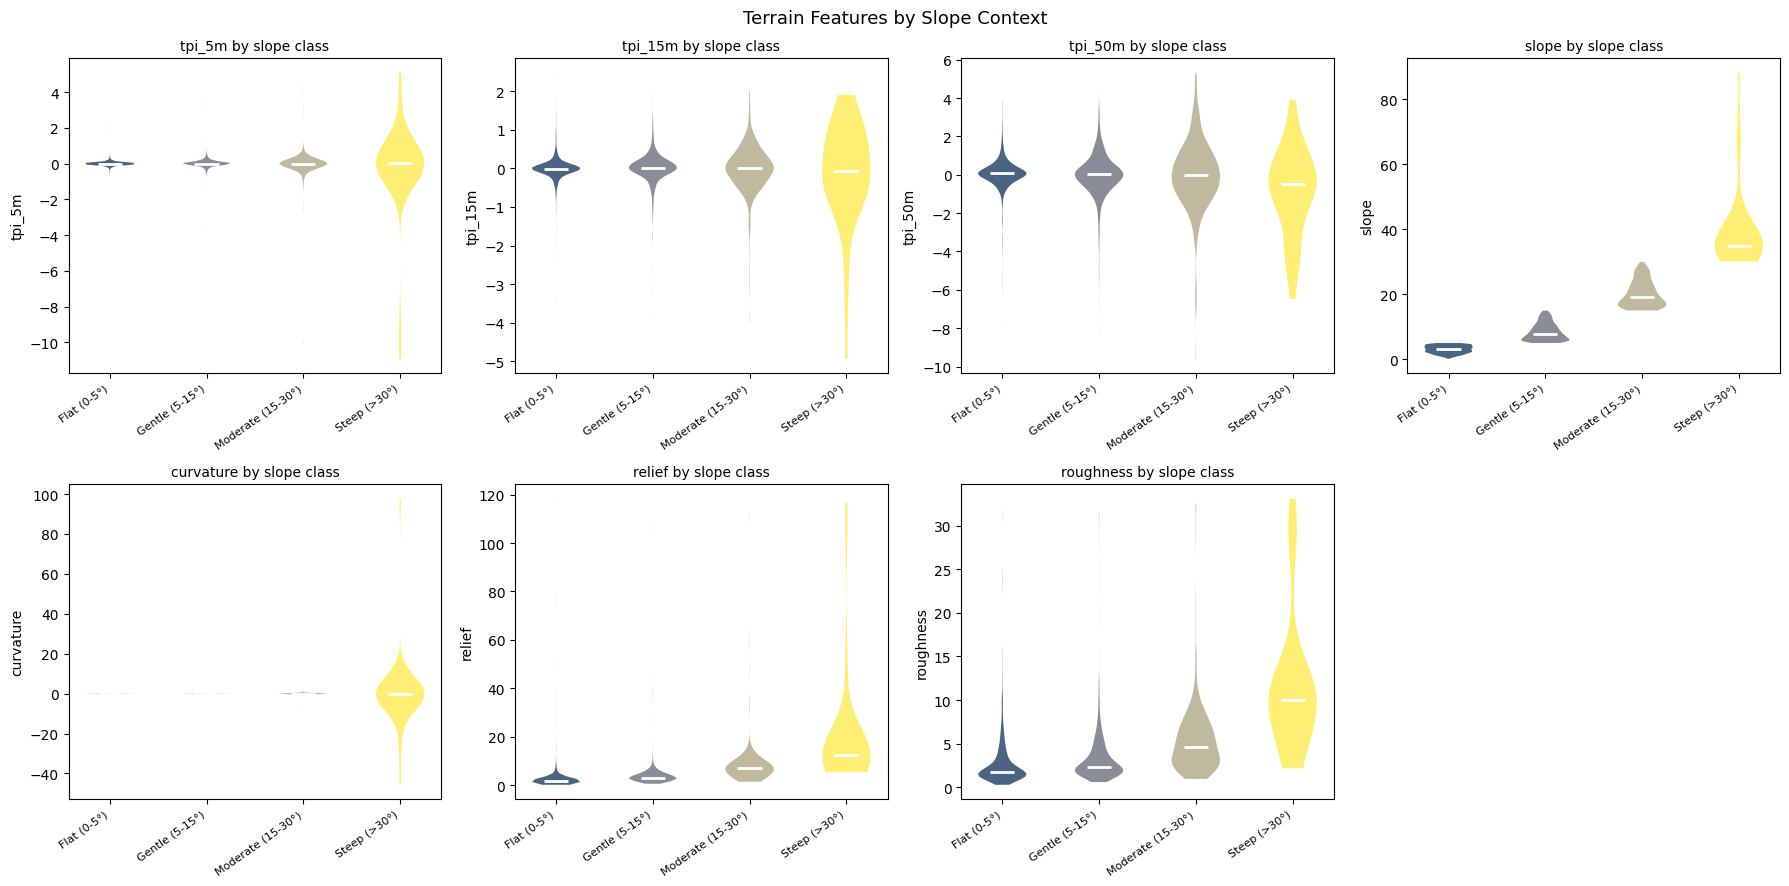

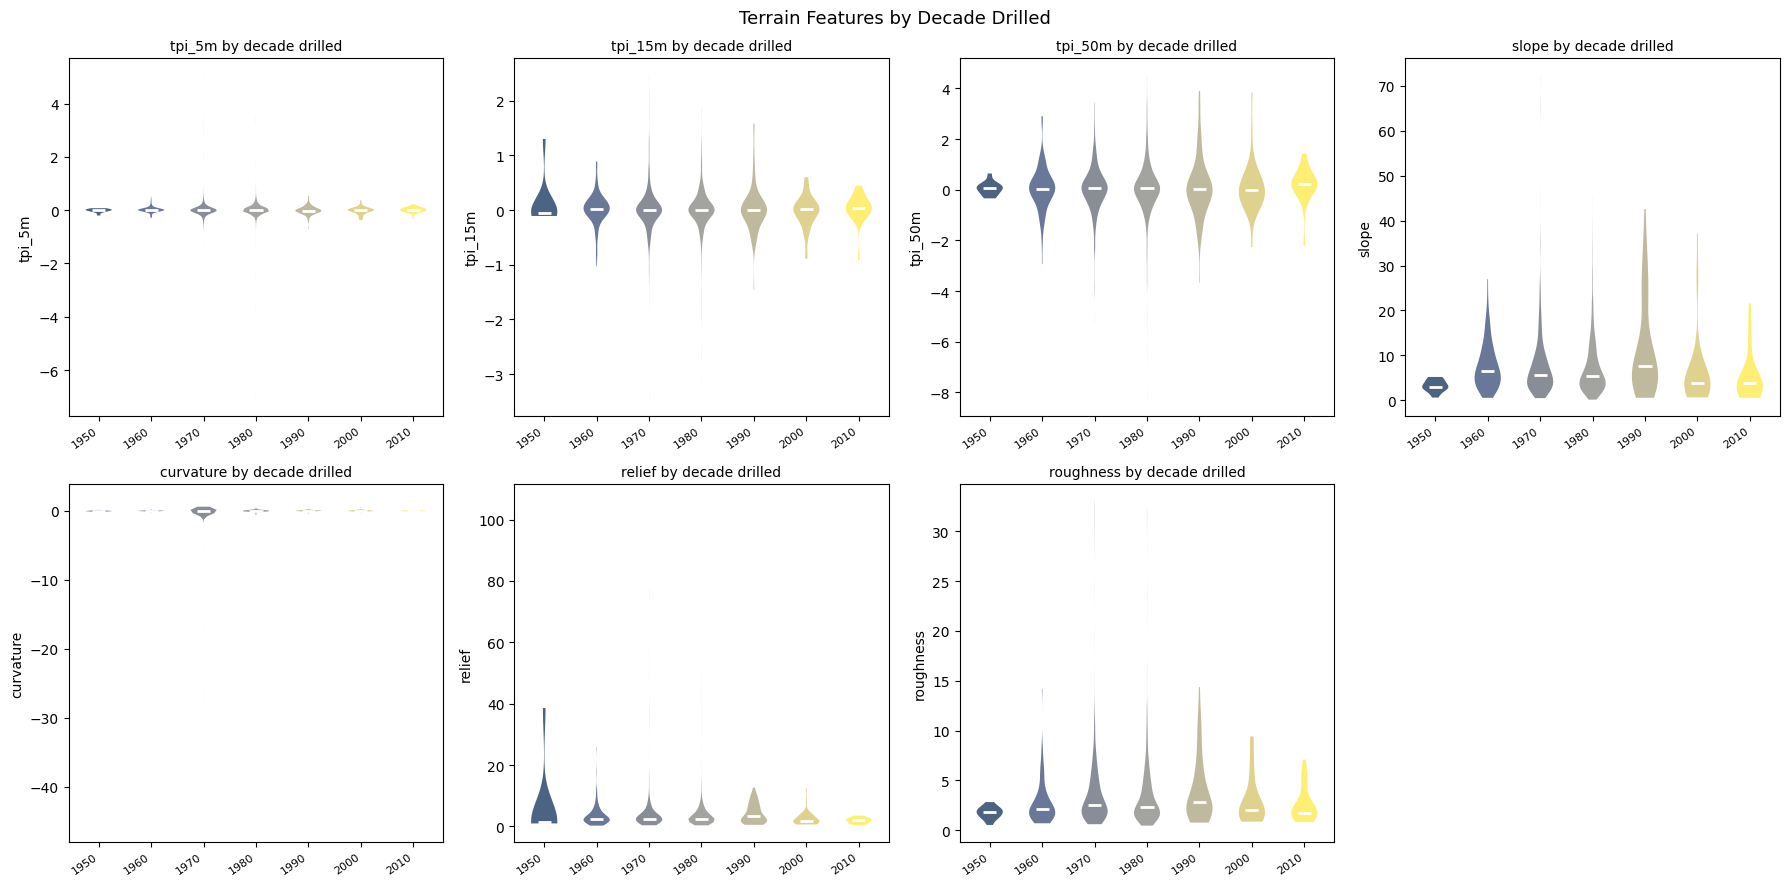


=== Mann-Whitney U: Wells vs Background ===
Null hypothesis: well and background distributions are identical
* = statistically significant at p < 0.05

  feature  well_median  bg_median      p_value significant
roughness     2.194362   1.782765 7.805878e-47           *
   relief     2.438927   2.156216 4.496142e-13           *
    slope     5.614168   5.172481 5.059403e-05           *
  tpi_15m     0.005873   0.007928 2.515996e-01            
curvature     0.004785   0.004066 4.088254e-01            
   tpi_5m    -0.002997  -0.000411 5.644021e-01            
  tpi_50m     0.040744   0.042478 6.813540e-01            


In [27]:
# ── Helper: violin plot by category ──────────────────────────────────────────
def violin_by_category(df, feature, groupby, title, ax, palette=None):
    groups   = df[groupby].dropna().unique()
    groups   = sorted([g for g in groups if pd.notna(g)])
    data     = [df.loc[df[groupby] == g, feature].dropna().values for g in groups]
    data     = [(d, g) for d, g in zip(data, groups) if len(d) > 5]
    if not data:
        ax.set_visible(False)
        return
    vals, labels = zip(*data)
    parts = ax.violinplot(vals, showmedians=True, showextrema=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_alpha(0.7)
        pc.set_facecolor(plt.cm.cividis(i / max(len(vals)-1, 1)))
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(feature)

# ── Helper: Mann-Whitney U test table ────────────────────────────────────────
def mw_test_table(wells, nonwell_vals, feature_cols):
    rows = []
    for feat in feature_cols:
        w = wells[feat].dropna()
        n = nonwell_vals[feat].dropna() if hasattr(nonwell_vals, '__getitem__') else nonwell_vals
        if len(w) < 5 or len(n) < 5:
            continue
        stat, p = stats.mannwhitneyu(w, n, alternative='two-sided')
        rows.append({
            'feature':    feat,
            'well_median': w.median(),
            'bg_median':  n.median(),
            'p_value':    p,
            'significant': '*' if p < 0.05 else ''
        })
    return pd.DataFrame(rows).sort_values('p_value')

feature_cols = list(RASTERS.keys())

# ── Figure 1: Wells vs background — overall distributions ────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

# Need background samples — reuse nonwell_features from all_samples if available
# otherwise re-extract
bg_df = all_samples[all_samples['label'] == 0][feature_cols]
w_df  = wells_enriched[feature_cols]

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    ax.violinplot([bg_df[feat].dropna(), w_df[feat].dropna()],
                  showmedians=True, showextrema=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Background', 'Well'], fontsize=10)
    ax.set_title(feat, fontsize=10)
    # Add p-value annotation
    stat, p = stats.mannwhitneyu(w_df[feat].dropna(), bg_df[feat].dropna(),
                                  alternative='two-sided')
    ax.set_xlabel(f'p={p:.4f}{"*" if p < 0.05 else ""}', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Terrain Feature Distributions: Wells vs Background', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\users\colto\documents\github\lidar_project\data\char_overall.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: By well type ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, feat in enumerate(feature_cols):
    violin_by_category(wells_enriched, feat, 'type',
                       f'{feat} by well type', axes[i])
axes[-1].set_visible(False)
plt.suptitle('Terrain Features by Well Type', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\users\colto\documents\github\lidar_project\data\char_by_type.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: By land cover ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, feat in enumerate(feature_cols):
    violin_by_category(wells_enriched, feat, 'nlcd_label',
                       f'{feat} by land cover', axes[i])
axes[-1].set_visible(False)
plt.suptitle('Terrain Features by Land Cover', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\users\colto\documents\github\lidar_project\data\char_by_landcover.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 4: By terrain slope context ───────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, feat in enumerate(feature_cols):
    violin_by_category(wells_enriched, feat, 'slope_class',
                       f'{feat} by slope class', axes[i])
axes[-1].set_visible(False)
plt.suptitle('Terrain Features by Slope Context', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\users\colto\documents\github\lidar_project\data\char_by_slope.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 5: By decade drilled ───────────────────────────────────────────────
age_wells = wells_enriched[wells_enriched['decade'].notna()].copy()
age_wells['decade'] = age_wells['decade'].astype(str)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, feat in enumerate(feature_cols):
    violin_by_category(age_wells, feat, 'decade',
                       f'{feat} by decade drilled', axes[i])
axes[-1].set_visible(False)
plt.suptitle('Terrain Features by Decade Drilled', fontsize=13)
plt.tight_layout()
plt.savefig(r'C:\users\colto\documents\github\lidar_project\data\char_by_decade.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical test summary ──────────────────────────────────────────────────
print("\n=== Mann-Whitney U: Wells vs Background ===")
print("Null hypothesis: well and background distributions are identical")
print("* = statistically significant at p < 0.05\n")
mw = mw_test_table(w_df, bg_df, feature_cols)
print(mw.to_string(index=False))